# 1. Imports

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import random
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight

from tqdm.notebook import tqdm

from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

import optuna
from pathlib import Path

# 2. Seeds and device

In [ ]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_all_seeds(42)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


print("Device:")
print(device)

Device:
cuda


# 3. File paths and main settings

In [ ]:
project_folder = Path("/content/drive/MyDrive/Dissertation_models")

data_folder = project_folder / "data"
processed_folder = data_folder / "processed"

outputs_folder = project_folder / "outputs_clean"

outputs_folder.mkdir(
    parents=True,
    exist_ok=True
)

master_file = processed_folder / "master_events.csv"


neutral_threshold = 0.0005

test_year = 2025

final_event_types = [
    "CPI",
    "GDP_ADVANCE",
    "NFP",
    "PCE",
    "RETAIL_SALES"
]


print("Master file:")
print(master_file)

print("\nOutputs folder:")
print(outputs_folder)

print("\nNeutral threshold:")
print(neutral_threshold)

print("\nTest year:")
print(test_year)

print("\nFinal event types:")
print(final_event_types)

Master file:
/content/drive/MyDrive/Dissertation_models/data/processed/master_events.csv

Outputs folder:
/content/drive/MyDrive/Dissertation_models/outputs_clean

Neutral threshold:
0.0005

Test year:
2025

Final event types:
['CPI', 'GDP_ADVANCE', 'NFP', 'PCE', 'RETAIL_SALES']


# 4. Load the master dataset

In [ ]:
events = pd.read_csv(master_file)

print("Raw events shape:")
print(events.shape)

print("\nColumns:")
print(events.columns.tolist())

Raw events shape:
(513, 62)

Columns:
['event_id', 'event_type', 'release_date', 'release_datetime_et', 'reference_period', 'average_hourly_earnings_mom_actual', 'average_hourly_earnings_mom_forecast', 'average_hourly_earnings_mom_previous', 'average_hourly_earnings_mom_surprise', 'core_cpi_mom_actual', 'core_cpi_mom_forecast', 'core_cpi_mom_previous', 'core_cpi_mom_surprise', 'core_pce_price_index_mom_actual', 'core_pce_price_index_mom_forecast', 'core_pce_price_index_mom_previous', 'core_pce_price_index_mom_surprise', 'gdp_growth_rate_qoq_advance_actual', 'gdp_growth_rate_qoq_advance_forecast', 'gdp_growth_rate_qoq_advance_previous', 'gdp_growth_rate_qoq_advance_surprise', 'headline_cpi_mom_actual', 'headline_cpi_mom_forecast', 'headline_cpi_mom_previous', 'headline_cpi_mom_surprise', 'nonfarm_payrolls_actual', 'nonfarm_payrolls_forecast', 'nonfarm_payrolls_previous', 'nonfarm_payrolls_surprise', 'retail_sales_mom_actual', 'retail_sales_mom_forecast', 'retail_sales_mom_previous', 're

# 5. Sort events and inspect existing labels

In [ ]:
events["release_datetime_et"] = pd.to_datetime(
    events["release_datetime_et"]
)

events["release_year"] = events["release_datetime_et"].dt.year

events = events.sort_values(
    by="release_datetime_et"
).reset_index(drop=True)


print("Events shape:")
print(events.shape)

print("\nDate range:")
print(events["release_datetime_et"].min())
print(events["release_datetime_et"].max())

print("\nEvent type counts:")
print(events["event_type"].value_counts().sort_index())

print("\nBinary label counts:")
print(events["label_binary"].value_counts().sort_index())

print("\n3-class label counts:")
print(events["label_3class_simple"].value_counts().sort_index())

Events shape:
(513, 63)

Date range:
2016-01-08 08:30:00
2025-12-23 08:30:00

Event type counts:
event_type
CPI             118
GDP_ADVANCE      40
NFP             119
PCE             117
RETAIL_SALES    119
Name: count, dtype: int64

Binary label counts:
label_binary
0    245
1    268
Name: count, dtype: int64

3-class label counts:
label_3class_simple
DOWN       166
NEUTRAL    141
UP         206
Name: count, dtype: int64


# 6. Remove failed market-window rows

In [ ]:
failed_rows = events[events["market_window_rows"] == 0].copy()

print("Failed market-window rows:")
print(failed_rows.shape[0])

display(
    failed_rows[
        [
            "event_id",
            "event_type",
            "release_datetime_et",
            "market_window_rows"
        ]
    ]
)


events = events[events["market_window_rows"] > 0].copy()
events = events.reset_index(drop=True)


print("Events shape after market-window filtering:")
print(events.shape)

print("\nEvent type counts:")
print(events["event_type"].value_counts().sort_index())

print("\nBinary label counts:")
print(events["label_binary"].value_counts().sort_index())

print("\n3-class label counts:")
print(events["label_3class_simple"].value_counts().sort_index())

Failed market-window rows:
4


,event_id,event_type,release_datetime_et,market_window_rows
66,CPI_2017_04,CPI,2017-04-14 08:30:00,0
67,RETAIL_SALES_2017_04,RETAIL_SALES,2017-04-14 08:30:00,0
221,CPI_2020_04,CPI,2020-04-10 08:30:00,0
427,PCE_2024_03,PCE,2024-03-29 08:30:00,0


Events shape after market-window filtering:
(509, 63)

Event type counts:
event_type
CPI             116
GDP_ADVANCE      40
NFP             119
PCE             116
RETAIL_SALES    118
Name: count, dtype: int64

Binary label counts:
label_binary
0    241
1    268
Name: count, dtype: int64

3-class label counts:
label_3class_simple
DOWN       166
NEUTRAL    137
UP         206
Name: count, dtype: int64


# 8. Load FinBERT embeddings

In [ ]:
features_folder = project_folder / "data" / "features"

embeddings_file = features_folder / "finbert_cls_embeddings.npy"
embedding_ids_file = features_folder / "embedding_event_ids.csv"

finbert_embeddings = np.load(
    embeddings_file
)

embedding_ids = pd.read_csv(
    embedding_ids_file
)

print("Embedding shape:")
print(finbert_embeddings.shape)

print("\nEmbedding IDs shape:")
print(embedding_ids.shape)

print("\nFirst embedding IDs:")
display(embedding_ids.head())

Embedding shape:
(513, 768)

Embedding IDs shape:
(513, 1)

First embedding IDs:


,event_id
0,NFP_2016_01
1,RETAIL_SALES_2016_01
2,CPI_2016_01
3,GDP_ADVANCE_2016_Q4
4,PCE_2016_02_2016-02-01


# 9. Align FinBERT embeddings with filtered events

In [ ]:
embedding_lookup = pd.DataFrame(finbert_embeddings, index=embedding_ids["event_id"])

missing_embedding_ids = []

for event_id in events["event_id"]:

    if event_id not in embedding_lookup.index:
        missing_embedding_ids.append(event_id)


print("Missing embedding IDs:")
print(len(missing_embedding_ids))

if len(missing_embedding_ids) > 0:
    print(missing_embedding_ids)


finbert_embeddings_aligned = embedding_lookup.loc[events["event_id"]].values


print("\nFiltered events shape:")
print(events.shape)

print("\nAligned FinBERT embedding shape:")
print(finbert_embeddings_aligned.shape)


same_number_of_rows = events.shape[0] == finbert_embeddings_aligned.shape[0]

print("\nSame number of rows:")
print(same_number_of_rows)

Missing embedding IDs:
0

Filtered events shape:
(509, 63)

Aligned FinBERT embedding shape:
(509, 768)

Same number of rows:
True


# 10. Create target variables

In [ ]:
y_binary = events["label_binary"].astype(int)

if events["label_3class_simple"].dtype == "object":

    label_mapping = {
        "DOWN": 0,
        "NEUTRAL": 1,
        "UP": 2
    }

    y_3class = events["label_3class_simple"].map(label_mapping)

else:

    y_3class = events["label_3class_simple"]


print("Missing 3-class labels after mapping:")
print(y_3class.isna().sum())

y_3class = y_3class.astype(int)


print("\nBinary target counts:")
print(y_binary.value_counts().sort_index())

print("\n3-class target counts:")
print(y_3class.value_counts().sort_index())

print("\nClass meanings:")
print("Binary: 0 = DOWN, 1 = UP")
print("3-class: 0 = DOWN, 1 = NEUTRAL, 2 = UP")

Missing 3-class labels after mapping:
0

Binary target counts:
label_binary
0    241
1    268
Name: count, dtype: int64

3-class target counts:
label_3class_simple
0    166
1    137
2    206
Name: count, dtype: int64

Class meanings:
Binary: 0 = DOWN, 1 = UP
3-class: 0 = DOWN, 1 = NEUTRAL, 2 = UP


# 11. Define context feature columns

In [ ]:
surprise_columns = [
    "average_hourly_earnings_mom_surprise",
    "core_cpi_mom_surprise",
    "core_pce_price_index_mom_surprise",
    "gdp_growth_rate_qoq_advance_surprise",
    "headline_cpi_mom_surprise",
    "nonfarm_payrolls_surprise",
    "retail_sales_mom_surprise",
    "unemployment_rate_surprise"
]

market_context_columns = [
    "vix_previous_close",
    "pre_event_realised_volatility"
]


context_numeric_columns = []

for column in surprise_columns:

    if column in events.columns:
        context_numeric_columns.append(column)

    else:
        print("Missing surprise column:")
        print(column)


for column in market_context_columns:

    if column in events.columns:
        context_numeric_columns.append(column)

    else:
        print("Missing market context column:")
        print(column)


print("Context numeric columns:")
print(context_numeric_columns)

print("\nNumber of numeric context columns:")
print(len(context_numeric_columns))

Context numeric columns:
['average_hourly_earnings_mom_surprise', 'core_cpi_mom_surprise', 'core_pce_price_index_mom_surprise', 'gdp_growth_rate_qoq_advance_surprise', 'headline_cpi_mom_surprise', 'nonfarm_payrolls_surprise', 'retail_sales_mom_surprise', 'unemployment_rate_surprise', 'vix_previous_close', 'pre_event_realised_volatility']

Number of numeric context columns:
10


In [ ]:
label_balance_data = events[["release_year"]].copy()

label_balance_data["binary_label"] = y_binary.values
label_balance_data["threeclass_label"] = y_3class.values


label_balance_rows = []

for year in sorted(label_balance_data["release_year"].unique()):

    year_data = label_balance_data[label_balance_data["release_year"] == year].copy()

    total_events = len(year_data)

    binary_down = (year_data["binary_label"] == 0).sum()
    binary_up = (year_data["binary_label"] == 1).sum()

    threeclass_down = (year_data["threeclass_label"] == 0).sum()
    threeclass_neutral = (year_data["threeclass_label"] == 1).sum()
    threeclass_up = (year_data["threeclass_label"] == 2).sum()

    label_balance_rows.append({
        "Year": year,
        "Events": total_events,
        "Binary DOWN (%)": round((binary_down / total_events) * 100, 2),
        "Binary UP (%)": round((binary_up / total_events) * 100, 2),
        "3-Class DOWN (%)": round((threeclass_down / total_events) * 100, 2),
        "3-Class NEUTRAL (%)": round((threeclass_neutral / total_events) * 100, 2),
        "3-Class UP (%)": round((threeclass_up / total_events) * 100, 2)
    })


label_balance_percent_table = pd.DataFrame(label_balance_rows)

display(label_balance_percent_table)

,Year,Events,Binary DOWN (%),Binary UP (%),3-Class DOWN (%),3-Class NEUTRAL (%),3-Class UP (%)
0,2016,52,50.00,50.00,26.92,38.46,34.62
1,2017,50,48.00,52.00,16.00,40.00,44.00
2,2018,52,51.92,48.08,32.69,32.69,34.62
3,2019,51,29.41,70.59,15.69,43.14,41.18
4,2020,51,50.98,49.02,45.10,13.73,41.18
5,2021,52,34.62,65.38,23.08,25.00,51.92
6,2022,52,67.31,32.69,48.08,19.23,32.69
7,2023,52,34.62,65.38,34.62,11.54,53.85
8,2024,51,49.02,50.98,45.10,19.61,35.29
9,2025,46,58.70,41.30,39.13,26.09,34.78


# 12. Create raw context feature matrix

In [ ]:
context_numeric = events[context_numeric_columns].copy()

event_type_dummies = pd.get_dummies(
    events["event_type"],
    prefix="event_type",
    dtype=int
)

context_features_raw = pd.concat([context_numeric, event_type_dummies], axis=1)


print("Context feature shape:")
print(context_features_raw.shape)

print("\nContext feature columns:")
print(context_features_raw.columns.tolist())

display(context_features_raw.head())

Context feature shape:
(509, 15)

Context feature columns:
['average_hourly_earnings_mom_surprise', 'core_cpi_mom_surprise', 'core_pce_price_index_mom_surprise', 'gdp_growth_rate_qoq_advance_surprise', 'headline_cpi_mom_surprise', 'nonfarm_payrolls_surprise', 'retail_sales_mom_surprise', 'unemployment_rate_surprise', 'vix_previous_close', 'pre_event_realised_volatility', 'event_type_CPI', 'event_type_GDP_ADVANCE', 'event_type_NFP', 'event_type_PCE', 'event_type_RETAIL_SALES']


,average_hourly_earnings_mom_surprise,core_cpi_mom_surprise,core_pce_price_index_mom_surprise,gdp_growth_rate_qoq_advance_surprise,headline_cpi_mom_surprise,nonfarm_payrolls_surprise,retail_sales_mom_surprise,unemployment_rate_surprise,vix_previous_close,pre_event_realised_volatility,event_type_CPI,event_type_GDP_ADVANCE,event_type_NFP,event_type_PCE,event_type_RETAIL_SALES
0,-0.2,NaN,NaN,NaN,NaN,92000.0,NaN,NaN,24.99,0.003872,0,0,1,0,0
1,NaN,NaN,NaN,NaN,NaN,NaN,-0.2,NaN,23.95,0.003368,0,0,0,0,1
2,NaN,-0.1,NaN,NaN,-0.1,NaN,NaN,NaN,26.05,0.002152,1,0,0,0,0
3,NaN,NaN,NaN,-0.1,NaN,NaN,NaN,NaN,22.42,0.002199,0,1,0,0,0
4,NaN,NaN,-0.1,NaN,NaN,NaN,NaN,NaN,20.20,0.001380,0,0,0,1,0


# 13. Feature leakage safety check

In [ ]:
blocked_exact_columns = [
    "price_post_end",
    "price_at_event",
    "price_pre_start",
    "post_event_30min_return",
    "post_event_30min_return_simple",
    "post_event_30min_return_pct",
    "official_text_length",
    "market_window_rows",
    "market_feature_error",
    "pre_event_return",
    "pre_event_return_simple",
    "pre_event_return_pct",
    "label_binary",
    "label_3class",
    "label_three_class",
    "label_3class_simple",
    "release_year"
]

bad_columns_found = []

for column in context_features_raw.columns:
    bad_column = False

    if column in blocked_exact_columns:
        bad_column = True

    if column.endswith("_actual"):
        bad_column = True

    if column.endswith("_forecast"):
        bad_column = True

    if column.endswith("_previous"):
        bad_column = True

    if "post_event" in column.lower():
        bad_column = True

    if bad_column == True:
        bad_columns_found.append(column)


print("Bad columns found:")
print(bad_columns_found)

if len(bad_columns_found) == 0:
    print("Feature safety check passed.")
else:
    print("Feature safety check failed.")


assert len(bad_columns_found) == 0

Bad columns found:
[]
Feature safety check passed.


# 15. Define walk-forward validation folds

In [ ]:
folds = [
    {
        "fold": 1,
        "train_years": [2016, 2017, 2018, 2019],
        "validation_year": 2020
    },
    {
        "fold": 2,
        "train_years": [2016, 2017, 2018, 2019, 2020],
        "validation_year": 2021
    },
    {
        "fold": 3,
        "train_years": [2016, 2017, 2018, 2019, 2020, 2021],
        "validation_year": 2022
    },
    {
        "fold": 4,
        "train_years": [2016, 2017, 2018, 2019, 2020, 2021, 2022],
        "validation_year": 2023
    },
    {
        "fold": 5,
        "train_years": [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
        "validation_year": 2024
    }
]


fold_rows = []

for fold in folds:
    fold_rows.append({
        "fold": fold["fold"],
        "train_years": fold["train_years"],
        "validation_year": fold["validation_year"]
    })


folds_df = pd.DataFrame(fold_rows)

display(folds_df)

print("Final holdout test year:")
print(test_year)

,fold,train_years,validation_year
0,1,"[2016, 2017, 2018, 2019]",2020
1,2,"[2016, 2017, 2018, 2019, 2020]",2021
2,3,"[2016, 2017, 2018, 2019, 2020, 2021]",2022
3,4,"[2016, 2017, 2018, 2019, 2020, 2021, 2022]",2023
4,5,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]",2024


Final holdout test year:
2025


# 16. Create raw text and context feature matrices

In [ ]:
text_features_raw = pd.DataFrame(finbert_embeddings_aligned, index=events.index)

context_features_raw = context_features_raw.fillna(0)


print("Text feature shape:")
print(text_features_raw.shape)

print("\nContext feature shape:")
print(context_features_raw.shape)

print("\nMissing values in text features:")
print(text_features_raw.isna().sum().sum())

print("\nMissing values in context features:")
print(context_features_raw.isna().sum().sum())

Text feature shape:
(509, 768)

Context feature shape:
(509, 15)

Missing values in text features:
0

Missing values in context features:
0


## 16.1 PCA explained variance check

In [ ]:
train_mask = events["release_year"] < test_year

X_text_train_raw = text_features_raw.loc[train_mask].copy()

text_scaler = StandardScaler()
X_text_train_scaled = text_scaler.fit_transform(X_text_train_raw)

pca_5 = PCA(n_components=5, random_state=42)
pca_5.fit(X_text_train_scaled)

pca_5_explained_variance = pca_5.explained_variance_ratio_.sum() * 100

print("PCA components:")
print(5)

print("\nExplained variance retained:")
print(str(round(pca_5_explained_variance, 2)) + "%")

PCA components:
5

Explained variance retained:
74.71%


# 17. Check feature and target alignment

In [ ]:
same_text_rows = text_features_raw.shape[0] == events.shape[0]
same_context_rows = context_features_raw.shape[0] == events.shape[0]
same_binary_rows = y_binary.shape[0] == events.shape[0]
same_3class_rows = y_3class.shape[0] == events.shape[0]

print("Text rows match events:")
print(same_text_rows)

print("\nContext rows match events:")
print(same_context_rows)

print("\nBinary target rows match events:")
print(same_binary_rows)

print("\n3-class target rows match events:")
print(same_3class_rows)

print("\nFinal events shape:")
print(events.shape)

Text rows match events:
True

Context rows match events:
True

Binary target rows match events:
True

3-class target rows match events:
True

Final events shape:
(509, 63)


# 18. Create fold feature preparation function

In [ ]:
def prepare_fold_features(train_mask, validation_mask, y_target, feature_set, pca_components):

    # Text features
    X_text_train_raw = text_features_raw.loc[train_mask].copy()
    X_text_validation_raw = text_features_raw.loc[validation_mask].copy()

    text_scaler = StandardScaler()

    X_text_train_scaled = text_scaler.fit_transform(X_text_train_raw)
    X_text_validation_scaled = text_scaler.transform(X_text_validation_raw)

    pca = PCA(n_components=pca_components, random_state=42)

    X_text_train_pca = pca.fit_transform(X_text_train_scaled)
    X_text_validation_pca = pca.transform(X_text_validation_scaled)

    pca_columns = []

    for i in range(pca_components):
        pca_columns.append("finbert_pca_" + str(i + 1))

    X_text_train = pd.DataFrame(X_text_train_pca, columns=pca_columns, index=X_text_train_raw.index)
    X_text_validation = pd.DataFrame(X_text_validation_pca, columns=pca_columns, index=X_text_validation_raw.index)


    # Context features
    X_context_train_raw = context_features_raw.loc[train_mask].copy()
    X_context_validation_raw = context_features_raw.loc[validation_mask].copy()

    context_scaler = StandardScaler()

    X_context_train_scaled = context_scaler.fit_transform(X_context_train_raw)
    X_context_validation_scaled = context_scaler.transform(X_context_validation_raw)

    X_context_train = pd.DataFrame(
        X_context_train_scaled,
        columns=context_features_raw.columns,
        index=X_context_train_raw.index
    )

    X_context_validation = pd.DataFrame(
        X_context_validation_scaled,
        columns=context_features_raw.columns,
        index=X_context_validation_raw.index
    )


    # Choose feature set
    if feature_set == "text_only":

        X_train = X_text_train.copy()
        X_validation = X_text_validation.copy()

    elif feature_set == "context_only":

        X_train = X_context_train.copy()
        X_validation = X_context_validation.copy()

    elif feature_set == "fused":

        X_train = pd.concat([X_context_train, X_text_train], axis=1)
        X_validation = pd.concat([X_context_validation, X_text_validation], axis=1)

    else:

        raise ValueError("Unknown feature set")


    y_train = y_target.loc[train_mask].copy()
    y_validation = y_target.loc[validation_mask].copy()

    return X_train, X_validation, y_train, y_validation

# 19. Create metric helper function

In [ ]:
def get_classification_scores(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    scores = {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1
    }

    return scores

# 20. Define MLP model

In [ ]:
class EventMLP(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):
        super(EventMLP, self).__init__()

        self.hidden_layer = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(hidden_size, output_size)


    def forward(self, x):

        x = self.hidden_layer(x)
        x = self.relu(x)
        x = self.output_layer(x)

        return x

# 21. Create inner split for MLP early stopping

In [ ]:
def create_inner_split(X_train, y_train, validation_fraction):

    split_point = int(len(X_train) * (1 - validation_fraction))

    X_inner_train = X_train.iloc[:split_point].copy()
    X_inner_validation = X_train.iloc[split_point:].copy()

    y_inner_train = y_train.iloc[:split_point].copy()
    y_inner_validation = y_train.iloc[split_point:].copy()

    return X_inner_train, X_inner_validation, y_inner_train, y_inner_validation

# 22. Train MLP model

In [ ]:
def train_mlp_model(X_train, y_train, output_size, hidden_size, learning_rate, weight_decay, batch_size, max_epochs, patience):

    X_inner_train, X_inner_validation, y_inner_train, y_inner_validation = create_inner_split(X_train, y_train, 0.2)

    X_inner_train_tensor = torch.tensor(X_inner_train.values, dtype=torch.float32)
    y_inner_train_tensor = torch.tensor(y_inner_train.values, dtype=torch.long)

    X_inner_validation_tensor = torch.tensor(X_inner_validation.values, dtype=torch.float32).to(device)
    y_inner_validation_values = y_inner_validation.values

    train_dataset = TensorDataset(X_inner_train_tensor, y_inner_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    input_size = X_train.shape[1]

    model = EventMLP(input_size, hidden_size, output_size).to(device)

    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    best_inner_macro_f1 = -1
    best_epoch = 0
    epochs_without_improvement = 0
    best_model_state = None

    history_rows = []

    for epoch in range(max_epochs):

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = loss_function(outputs, y_batch)

            loss.backward()
            optimizer.step()

        train_predictions = predict_mlp_model(model, X_inner_train, batch_size)
        train_scores = get_classification_scores(y_inner_train, train_predictions)

        model.eval()

        with torch.no_grad():

            inner_outputs = model(X_inner_validation_tensor)

            inner_predictions_tensor = torch.argmax(inner_outputs, dim=1)
            inner_predictions = inner_predictions_tensor.cpu().numpy()

        inner_scores = get_classification_scores(y_inner_validation_values, inner_predictions)

        history_rows.append(
            {
                "epoch": epoch + 1,
                "train_macro_f1": train_scores["macro_f1"],
                "inner_validation_macro_f1": inner_scores["macro_f1"],
                "train_accuracy": train_scores["accuracy"],
                "inner_validation_accuracy": inner_scores["accuracy"]
            }
        )

        if inner_scores["macro_f1"] > best_inner_macro_f1:

            best_inner_macro_f1 = inner_scores["macro_f1"]
            best_epoch = epoch + 1
            epochs_without_improvement = 0

            best_model_state = {}

            for key, value in model.state_dict().items():
                best_model_state[key] = value.detach().cpu().clone()

        else:

            epochs_without_improvement = epochs_without_improvement + 1

        if epochs_without_improvement >= patience:
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    history_df = pd.DataFrame(history_rows)

    return model, history_df, best_epoch

# 22. Predict using MLP model

In [ ]:
def predict_mlp_model(model, X_data, batch_size):

    X_tensor = torch.tensor(X_data.values, dtype=torch.float32)

    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    predictions_list = []

    model.eval()

    with torch.no_grad():

        for batch in loader:

            X_batch = batch[0].to(device)

            outputs = model(X_batch)
            predictions = torch.argmax(outputs, dim=1)

            predictions_list.append(predictions.cpu().numpy())


    predictions = np.concatenate(predictions_list)

    return predictions

# **Walk Forward functions**

## 23.1. Logistic Regression walk-forward function

In [ ]:
def run_logistic_walk_forward(y_target, feature_set, output_size, pca_components, C, penalty):

    result_rows = []

    for fold in folds:

        train_mask = events["release_year"].isin(fold["train_years"])
        validation_mask = events["release_year"] == fold["validation_year"]

        X_train, X_validation, y_train, y_validation = prepare_fold_features(
            train_mask,
            validation_mask,
            y_target,
            feature_set,
            pca_components
        )

        model = LogisticRegression(
            C=C,
            penalty=penalty,
            solver="liblinear",
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_train, y_train)

        train_predictions = model.predict(X_train)
        validation_predictions = model.predict(X_validation)

        train_scores = get_classification_scores(y_train, train_predictions)
        validation_scores = get_classification_scores(y_validation, validation_predictions)

        result_rows.append({
            "fold": fold["fold"],
            "validation_year": fold["validation_year"],
            "feature_set": feature_set,
            "model": "Logistic Regression",
            "train_macro_f1": train_scores["macro_f1"],
            "validation_macro_f1": validation_scores["macro_f1"],
            "validation_accuracy": validation_scores["accuracy"],
            "validation_balanced_accuracy": validation_scores["balanced_accuracy"]
        })

    results_df = pd.DataFrame(result_rows)

    return results_df

## 23.2. XGBoost walk-forward function

In [ ]:
def run_xgboost_walk_forward(y_target, feature_set, output_size, pca_components, xgboost_params):

    result_rows = []

    for fold in folds:

        train_mask = events["release_year"].isin(fold["train_years"])
        validation_mask = events["release_year"] == fold["validation_year"]

        X_train, X_validation, y_train, y_validation = prepare_fold_features(
            train_mask,
            validation_mask,
            y_target,
            feature_set,
            pca_components
        )

        if output_size == 2:

            negative_count = (y_train == 0).sum()
            positive_count = (y_train == 1).sum()

            if positive_count > 0:
                scale_pos_weight = negative_count / positive_count
            else:
                scale_pos_weight = 1

            model = XGBClassifier(
                n_estimators=xgboost_params["n_estimators"],
                max_depth=xgboost_params["max_depth"],
                learning_rate=xgboost_params["learning_rate"],
                min_child_weight=xgboost_params["min_child_weight"],
                subsample=xgboost_params["subsample"],
                colsample_bytree=xgboost_params["colsample_bytree"],
                reg_lambda=xgboost_params["reg_lambda"],
                reg_alpha=xgboost_params["reg_alpha"],
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=42
            )

            model.fit(X_train, y_train)

        else:

            sample_weights = compute_sample_weight(
                class_weight="balanced",
                y=y_train
            )

            model = XGBClassifier(
                n_estimators=xgboost_params["n_estimators"],
                max_depth=xgboost_params["max_depth"],
                learning_rate=xgboost_params["learning_rate"],
                min_child_weight=xgboost_params["min_child_weight"],
                subsample=xgboost_params["subsample"],
                colsample_bytree=xgboost_params["colsample_bytree"],
                reg_lambda=xgboost_params["reg_lambda"],
                reg_alpha=xgboost_params["reg_alpha"],
                objective="multi:softprob",
                num_class=output_size,
                eval_metric="mlogloss",
                random_state=42
            )

            model.fit(X_train, y_train, sample_weight=sample_weights)

        train_predictions = model.predict(X_train)
        validation_predictions = model.predict(X_validation)

        train_scores = get_classification_scores(y_train, train_predictions)
        validation_scores = get_classification_scores(y_validation, validation_predictions)

        result_rows.append({
            "fold": fold["fold"],
            "validation_year": fold["validation_year"],
            "feature_set": feature_set,
            "model": "XGBoost",
            "train_macro_f1": train_scores["macro_f1"],
            "validation_macro_f1": validation_scores["macro_f1"],
            "validation_accuracy": validation_scores["accuracy"],
            "validation_balanced_accuracy": validation_scores["balanced_accuracy"]
        })

    results_df = pd.DataFrame(result_rows)

    return results_df

## 23.3. MLP walk-forward function

In [ ]:
def run_mlp_walk_forward(y_target, feature_set, output_size, pca_components, mlp_params):

    result_rows = []
    history_rows = []

    for fold in folds:

        train_mask = events["release_year"].isin(fold["train_years"])
        validation_mask = events["release_year"] == fold["validation_year"]

        X_train, X_validation, y_train, y_validation = prepare_fold_features(
            train_mask,
            validation_mask,
            y_target,
            feature_set,
            pca_components
        )

        set_all_seeds(42 + fold["fold"])

        model, history_df, best_epoch = train_mlp_model(
            X_train,
            y_train,
            output_size,
            mlp_params["hidden_size"],
            mlp_params["learning_rate"],
            mlp_params["weight_decay"],
            mlp_params["batch_size"],
            mlp_params["max_epochs"],
            mlp_params["patience"]
        )

        train_predictions = predict_mlp_model(model, X_train, mlp_params["batch_size"])
        validation_predictions = predict_mlp_model(model, X_validation, mlp_params["batch_size"])

        train_scores = get_classification_scores(y_train, train_predictions)
        validation_scores = get_classification_scores(y_validation, validation_predictions)

        result_rows.append({
            "fold": fold["fold"],
            "validation_year": fold["validation_year"],
            "feature_set": feature_set,
            "model": "MLP",
            "train_macro_f1": train_scores["macro_f1"],
            "validation_macro_f1": validation_scores["macro_f1"],
            "validation_accuracy": validation_scores["accuracy"],
            "validation_balanced_accuracy": validation_scores["balanced_accuracy"],
            "best_epoch": best_epoch
        })

        history_df["fold"] = fold["fold"]
        history_df["validation_year"] = fold["validation_year"]
        history_df["feature_set"] = feature_set
        history_df["output_size"] = output_size

        history_rows.append(history_df)

    results_df = pd.DataFrame(result_rows)
    history_df_all = pd.concat(history_rows, axis=0).reset_index(drop=True)

    return results_df, history_df_all

# 24. Fixed baseline settings

In [ ]:
feature_sets = [
    "text_only",
    "context_only",
    "fused"
]


logistic_baseline_params = {
    "C": 0.1,
    "penalty": "l2",
    "pca_components": 5
}


xgboost_baseline_params = {
    "n_estimators": 100,
    "max_depth": 2,
    "learning_rate": 0.05,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 5,
    "reg_alpha": 1,
    "pca_components": 5
}


mlp_baseline_params = {
    "hidden_size": 16,
    "learning_rate": 0.001,
    "weight_decay": 0.01,
    "batch_size": 16,
    "max_epochs": 100,
    "patience": 10,
    "pca_components": 5
}


print("Fixed baseline settings created.")

Fixed baseline settings created.


# 25. Run fixed 3x3 baseline for binary target

In [ ]:
binary_baseline_results_list = []
binary_mlp_history_list = []

for feature_set in feature_sets:

    print("Running binary baseline:", feature_set)

    logistic_results = run_logistic_walk_forward(
        y_target=y_binary,
        feature_set=feature_set,
        output_size=2,
        pca_components=logistic_baseline_params["pca_components"],
        C=logistic_baseline_params["C"],
        penalty=logistic_baseline_params["penalty"]
    )

    xgboost_results = run_xgboost_walk_forward(
        y_target=y_binary,
        feature_set=feature_set,
        output_size=2,
        pca_components=xgboost_baseline_params["pca_components"],
        xgboost_params=xgboost_baseline_params
    )

    mlp_results, mlp_history = run_mlp_walk_forward(
        y_target=y_binary,
        feature_set=feature_set,
        output_size=2,
        pca_components=mlp_baseline_params["pca_components"],
        mlp_params=mlp_baseline_params
    )

    mlp_history["target"] = "binary"
    binary_mlp_history_list.append(mlp_history)

    binary_baseline_results_list.append(logistic_results)
    binary_baseline_results_list.append(xgboost_results)
    binary_baseline_results_list.append(mlp_results)


binary_baseline_results = pd.concat(binary_baseline_results_list, axis=0).reset_index(drop=True)
binary_mlp_history = pd.concat(binary_mlp_history_list, axis=0).reset_index(drop=True)

print("Binary baseline results shape:")
print(binary_baseline_results.shape)

print("\nBinary MLP history shape:")
print(binary_mlp_history.shape)

display(binary_baseline_results.head())

Running binary baseline: text_only
Running binary baseline: context_only
Running binary baseline: fused
Binary baseline results shape:
(45, 9)

Binary MLP history shape:
(267, 10)


,fold,validation_year,feature_set,model,train_macro_f1,validation_macro_f1,validation_accuracy,validation_balanced_accuracy,best_epoch
0,1,2020,text_only,Logistic Regression,0.554571,0.514286,0.529412,0.526154,NaN
1,2,2021,text_only,Logistic Regression,0.538612,0.583683,0.596154,0.599673,NaN
2,3,2022,text_only,Logistic Regression,0.545378,0.446154,0.480769,0.447899,NaN
3,4,2023,text_only,Logistic Regression,0.527489,0.493253,0.500000,0.591503,NaN
4,5,2024,text_only,Logistic Regression,0.546092,0.449420,0.470588,0.474615,NaN


# 26. Run fixed 3x3 baseline for 3-class target

In [ ]:
threeclass_baseline_results_list = []
threeclass_mlp_history_list = []

for feature_set in feature_sets:

    print("Running 3-class baseline:", feature_set)

    logistic_results = run_logistic_walk_forward(
        y_target=y_3class,
        feature_set=feature_set,
        output_size=3,
        pca_components=logistic_baseline_params["pca_components"],
        C=logistic_baseline_params["C"],
        penalty=logistic_baseline_params["penalty"]
    )

    xgboost_results = run_xgboost_walk_forward(
        y_target=y_3class,
        feature_set=feature_set,
        output_size=3,
        pca_components=xgboost_baseline_params["pca_components"],
        xgboost_params=xgboost_baseline_params
    )

    mlp_results, mlp_history = run_mlp_walk_forward(
        y_target=y_3class,
        feature_set=feature_set,
        output_size=3,
        pca_components=mlp_baseline_params["pca_components"],
        mlp_params=mlp_baseline_params
    )

    mlp_history["target"] = "3-class"
    threeclass_mlp_history_list.append(mlp_history)

    threeclass_baseline_results_list.append(logistic_results)
    threeclass_baseline_results_list.append(xgboost_results)
    threeclass_baseline_results_list.append(mlp_results)


threeclass_baseline_results = pd.concat(threeclass_baseline_results_list, axis=0).reset_index(drop=True)
threeclass_mlp_history = pd.concat(threeclass_mlp_history_list, axis=0).reset_index(drop=True)

print("3-class baseline results shape:")
print(threeclass_baseline_results.shape)

print("\n3-class MLP history shape:")
print(threeclass_mlp_history.shape)

display(threeclass_baseline_results.head())

Running 3-class baseline: text_only
Running 3-class baseline: context_only
Running 3-class baseline: fused
3-class baseline results shape:
(45, 9)

3-class MLP history shape:
(279, 10)


,fold,validation_year,feature_set,model,train_macro_f1,validation_macro_f1,validation_accuracy,validation_balanced_accuracy,best_epoch
0,1,2020,text_only,Logistic Regression,0.451699,0.306713,0.352941,0.345066,NaN
1,2,2021,text_only,Logistic Regression,0.411037,0.367737,0.403846,0.369896,NaN
2,3,2022,text_only,Logistic Regression,0.420989,0.319771,0.326923,0.424314,NaN
3,4,2023,text_only,Logistic Regression,0.398886,0.314992,0.326923,0.440476,NaN
4,5,2024,text_only,Logistic Regression,0.404508,0.307018,0.313725,0.358293,NaN


# **27. MLP Learning Curves**

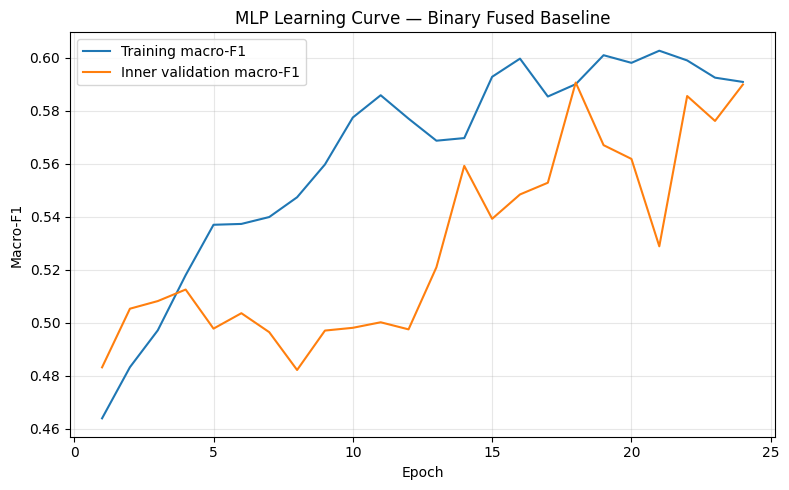

In [ ]:
binary_mlp_curve_df = binary_mlp_history[
    binary_mlp_history["feature_set"] == "fused"
].copy()

binary_mlp_curve_summary = binary_mlp_curve_df.groupby("epoch")[
    [
        "train_macro_f1",
        "inner_validation_macro_f1"
    ]
].mean().reset_index()


plt.figure(figsize=(8, 5))

plt.plot(
    binary_mlp_curve_summary["epoch"],
    binary_mlp_curve_summary["train_macro_f1"],
    label="Training macro-F1"
)

plt.plot(
    binary_mlp_curve_summary["epoch"],
    binary_mlp_curve_summary["inner_validation_macro_f1"],
    label="Inner validation macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("MLP Learning Curve — Binary Fused Baseline")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

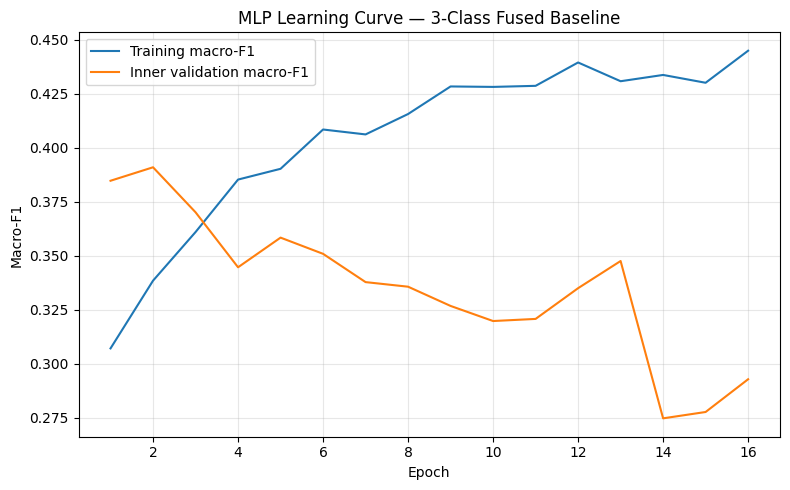

In [ ]:
mlp_curve_df = threeclass_mlp_history[
    threeclass_mlp_history["feature_set"] == "fused"
].copy()

mlp_curve_summary = mlp_curve_df.groupby("epoch")[
    [
        "train_macro_f1",
        "inner_validation_macro_f1"
    ]
].mean().reset_index()


plt.figure(figsize=(8, 5))

plt.plot(
    mlp_curve_summary["epoch"],
    mlp_curve_summary["train_macro_f1"],
    label="Training macro-F1"
)

plt.plot(
    mlp_curve_summary["epoch"],
    mlp_curve_summary["inner_validation_macro_f1"],
    label="Inner validation macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("MLP Learning Curve — 3-Class Fused Baseline")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 28. **Summarise binary fixed baseline results**

In [ ]:
binary_baseline_summary = binary_baseline_results.groupby(
    ["feature_set", "model"]
)["validation_macro_f1"].agg(["mean", "std"]).reset_index()

binary_baseline_summary = binary_baseline_summary.rename(
    columns={
        "mean": "mean_validation_macro_f1",
        "std": "std_validation_macro_f1"
    }
)

binary_baseline_summary = binary_baseline_summary.sort_values(
    by="mean_validation_macro_f1",
    ascending=False
).reset_index(drop=True)


print("Binary fixed baseline summary:")
display(binary_baseline_summary)

Binary fixed baseline summary:


,feature_set,model,mean_validation_macro_f1,std_validation_macro_f1
0,context_only,Logistic Regression,0.545071,0.047086
1,text_only,XGBoost,0.538668,0.061620
2,fused,Logistic Regression,0.516596,0.026968
3,context_only,XGBoost,0.509882,0.066963
4,fused,XGBoost,0.505828,0.031410
5,text_only,Logistic Regression,0.497359,0.056292
6,text_only,MLP,0.495985,0.055062
7,context_only,MLP,0.492172,0.072692
8,fused,MLP,0.484035,0.050536


# **29. Summarise 3-class baseline results**

In [ ]:
threeclass_baseline_summary = threeclass_baseline_results.groupby(
    ["feature_set", "model"]
)["validation_macro_f1"].agg(["mean", "std"]).reset_index()

threeclass_baseline_summary = threeclass_baseline_summary.rename(
    columns={
        "mean": "mean_validation_macro_f1",
        "std": "std_validation_macro_f1"
    }
)

threeclass_baseline_summary = threeclass_baseline_summary.sort_values(
    by="mean_validation_macro_f1",
    ascending=False
).reset_index(drop=True)


print("3-class fixed baseline summary:")
display(threeclass_baseline_summary)

3-class fixed baseline summary:


,feature_set,model,mean_validation_macro_f1,std_validation_macro_f1
0,fused,Logistic Regression,0.420653,0.051384
1,context_only,Logistic Regression,0.381684,0.039413
2,context_only,XGBoost,0.357437,0.033072
3,fused,XGBoost,0.337144,0.041757
4,context_only,MLP,0.332335,0.063022
5,text_only,Logistic Regression,0.323246,0.025477
6,text_only,XGBoost,0.322814,0.033944
7,fused,MLP,0.291993,0.080167
8,text_only,MLP,0.272296,0.078691


# **Binary Basline Summary graph**

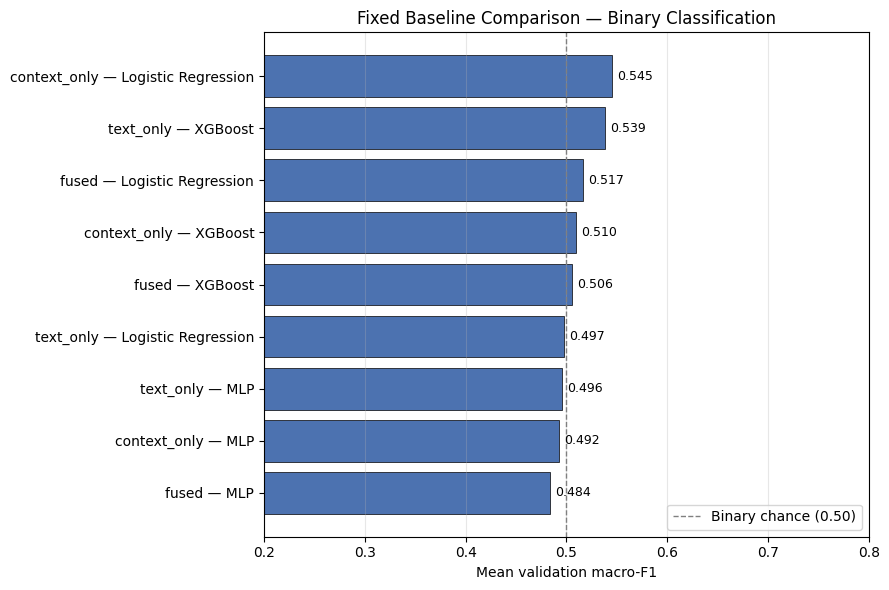

In [ ]:
binary_plot_df = binary_baseline_summary.copy()

binary_plot_df["model_label"] = (
    binary_plot_df["feature_set"] + " — " + binary_plot_df["model"]
)

binary_plot_df = binary_plot_df.sort_values(
    by="mean_validation_macro_f1",
    ascending=True
)


plt.figure(figsize=(9, 6))

bars = plt.barh(
    binary_plot_df["model_label"],
    binary_plot_df["mean_validation_macro_f1"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5
)

for bar, value in zip(bars, binary_plot_df["mean_validation_macro_f1"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.axvline(
    0.50,
    linestyle="--",
    linewidth=1,
    color="grey",
    label="Binary chance (0.50)"
)

plt.xlabel("Mean validation macro-F1")
plt.title("Fixed Baseline Comparison — Binary Classification")
plt.xlim(0.2, 0.8)
plt.grid(axis="x", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# **3-Class baseline summary graph**

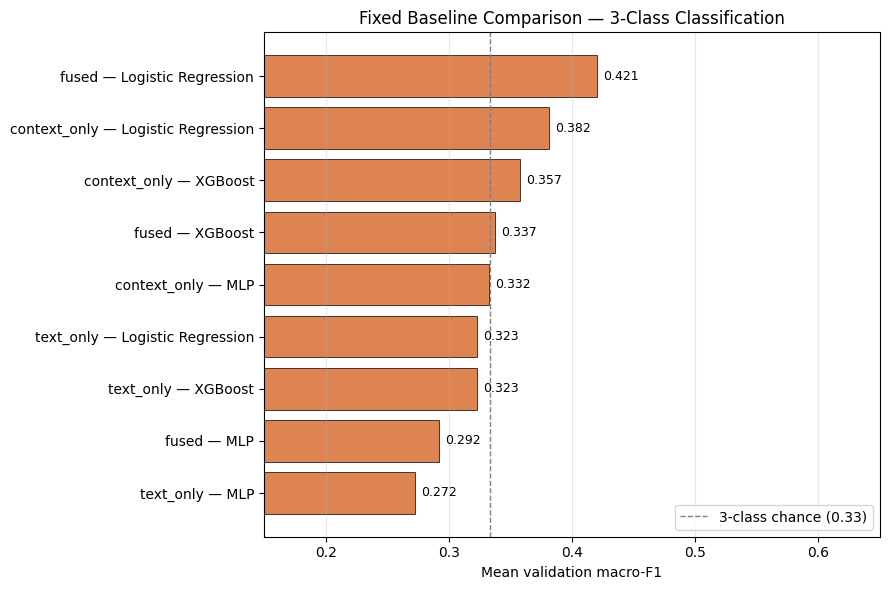

In [ ]:
threeclass_plot_df = threeclass_baseline_summary.copy()

threeclass_plot_df["model_label"] = (
    threeclass_plot_df["feature_set"] + " — " + threeclass_plot_df["model"]
)

threeclass_plot_df = threeclass_plot_df.sort_values(
    by="mean_validation_macro_f1",
    ascending=True
)


plt.figure(figsize=(9, 6))

bars = plt.barh(
    threeclass_plot_df["model_label"],
    threeclass_plot_df["mean_validation_macro_f1"],
    color="#DD8452",
    edgecolor="black",
    linewidth=0.5
)

for bar, value in zip(bars, threeclass_plot_df["mean_validation_macro_f1"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.axvline(
    1 / 3,
    linestyle="--",
    linewidth=1,
    color="grey",
    label="3-class chance (0.33)"
)

plt.xlabel("Mean validation macro-F1")
plt.title("Fixed Baseline Comparison — 3-Class Classification")
plt.xlim(0.15, 0.65)
plt.grid(axis="x", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# **30. Bayesian Optimization**

# Define optimisation settings

In [ ]:
optimised_feature_sets = [
    "context_only",
    "fused"
]

n_trials = 30

optuna_seed = 42


print("Optimised feature sets:")
print(optimised_feature_sets)

print("\nNumber of Optuna trials:")
print(n_trials)

print("\nOptuna seed:")
print(optuna_seed)

Optimised feature sets:
['context_only', 'fused']

Number of Optuna trials:
30

Optuna seed:
42


# 31. Logistic Regression Optuna objective

In [ ]:
def create_logistic_objective(y_target, feature_set, output_size):

    def objective(trial):

        C = trial.suggest_float("C", 0.01, 1.0, log=True)
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])

        if feature_set == "fused":
            pca_components = trial.suggest_categorical("pca_components", [1, 3, 5, 7, 9])
        else:
            pca_components = 5

        fold_results = run_logistic_walk_forward(
            y_target=y_target,
            feature_set=feature_set,
            output_size=output_size,
            pca_components=pca_components,
            C=C,
            penalty=penalty
        )

        mean_validation_macro_f1 = fold_results["validation_macro_f1"].mean()
        mean_train_macro_f1 = fold_results["train_macro_f1"].mean()
        validation_macro_f1_std = fold_results["validation_macro_f1"].std()
        train_validation_gap = mean_train_macro_f1 - mean_validation_macro_f1

        trial.set_user_attr("mean_train_macro_f1", mean_train_macro_f1)
        trial.set_user_attr("validation_macro_f1_std", validation_macro_f1_std)
        trial.set_user_attr("train_validation_gap", train_validation_gap)

        return mean_validation_macro_f1

    return objective

# 32. XGBoost Optuna objective

In [ ]:
def create_xgboost_objective(y_target, feature_set, output_size):

    def objective(trial):

        if feature_set == "fused":
            pca_components = trial.suggest_categorical("pca_components", [1, 3, 5, 7, 9])
        else:
            pca_components = 5

        xgboost_params = {
            "n_estimators": trial.suggest_int("n_estimators", 20, 100),
            "max_depth": trial.suggest_int("max_depth", 1, 2),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.06, log=True),
            "min_child_weight": trial.suggest_int("min_child_weight", 5, 25),
            "subsample": trial.suggest_float("subsample", 0.7, 0.9),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
            "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 50.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
            "pca_components": pca_components
        }

        fold_results = run_xgboost_walk_forward(
            y_target=y_target,
            feature_set=feature_set,
            output_size=output_size,
            pca_components=pca_components,
            xgboost_params=xgboost_params
        )

        mean_validation_macro_f1 = fold_results["validation_macro_f1"].mean()
        mean_train_macro_f1 = fold_results["train_macro_f1"].mean()
        validation_macro_f1_std = fold_results["validation_macro_f1"].std()
        train_validation_gap = mean_train_macro_f1 - mean_validation_macro_f1

        trial.set_user_attr("mean_train_macro_f1", mean_train_macro_f1)
        trial.set_user_attr("validation_macro_f1_std", validation_macro_f1_std)
        trial.set_user_attr("train_validation_gap", train_validation_gap)

        return mean_validation_macro_f1

    return objective

# 33. MLP Optuna objective

In [ ]:
def create_mlp_objective(y_target, feature_set, output_size):

    def objective(trial):

        if feature_set == "fused":
            pca_components = trial.suggest_categorical("pca_components", [1, 3, 5, 7, 9])
        else:
            pca_components = 5

        mlp_params = {
            "hidden_size": trial.suggest_categorical("hidden_size", [8, 16, 32]),
            "learning_rate": trial.suggest_float("learning_rate", 0.0005, 0.005, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 0.005, 0.05, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
            "max_epochs": 100,
            "patience": trial.suggest_categorical("patience", [10, 15, 20]),
            "pca_components": pca_components
        }

        fold_results, fold_history = run_mlp_walk_forward(
            y_target=y_target,
            feature_set=feature_set,
            output_size=output_size,
            pca_components=pca_components,
            mlp_params=mlp_params
        )

        mean_validation_macro_f1 = fold_results["validation_macro_f1"].mean()
        mean_train_macro_f1 = fold_results["train_macro_f1"].mean()
        validation_macro_f1_std = fold_results["validation_macro_f1"].std()
        train_validation_gap = mean_train_macro_f1 - mean_validation_macro_f1

        median_best_epoch = int(fold_results["best_epoch"].median())
        mean_best_epoch = fold_results["best_epoch"].mean()

        trial.set_user_attr("mean_train_macro_f1", mean_train_macro_f1)
        trial.set_user_attr("validation_macro_f1_std", validation_macro_f1_std)
        trial.set_user_attr("train_validation_gap", train_validation_gap)

        trial.set_user_attr("median_best_epoch", median_best_epoch)
        trial.set_user_attr("mean_best_epoch", mean_best_epoch)

        return mean_validation_macro_f1

    return objective

# 34. Run binary Optuna optimisation

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

binary_studies = {}

for feature_set in optimised_feature_sets:

    print("\n" + "=" * 70)
    print("Optimising binary models for:", feature_set)
    print("=" * 70)


    print("\nRunning Logistic Regression optimisation...")

    sampler = optuna.samplers.TPESampler(seed=optuna_seed)

    logistic_study = optuna.create_study(direction="maximize", sampler=sampler)

    logistic_study.optimize(
        create_logistic_objective(y_binary, feature_set, 2),
        n_trials=n_trials,
        show_progress_bar=True
    )

    binary_studies[(feature_set, "Logistic Regression")] = logistic_study

    print("Best Logistic validation macro-F1:")
    print(logistic_study.best_value)

    print("Train-validation gap:")
    print(logistic_study.best_trial.user_attrs["train_validation_gap"])

    print("Best params:")
    print(logistic_study.best_params)


    print("\nRunning XGBoost optimisation...")

    sampler = optuna.samplers.TPESampler(seed=optuna_seed)

    xgboost_study = optuna.create_study(direction="maximize", sampler=sampler)

    xgboost_study.optimize(
        create_xgboost_objective(y_binary, feature_set, 2),
        n_trials=n_trials,
        show_progress_bar=True
    )

    binary_studies[(feature_set, "XGBoost")] = xgboost_study

    print("Best XGBoost validation macro-F1:")
    print(xgboost_study.best_value)

    print("Train-validation gap:")
    print(xgboost_study.best_trial.user_attrs["train_validation_gap"])

    print("Best params:")
    print(xgboost_study.best_params)


    print("\nRunning MLP optimisation...")

    sampler = optuna.samplers.TPESampler(seed=optuna_seed)

    mlp_study = optuna.create_study(direction="maximize", sampler=sampler)

    mlp_study.optimize(
        create_mlp_objective(y_binary, feature_set, 2),
        n_trials=n_trials,
        show_progress_bar=True
    )

    binary_studies[(feature_set, "MLP")] = mlp_study

    print("Best MLP validation macro-F1:")
    print(mlp_study.best_value)

    print("Train-validation gap:")
    print(mlp_study.best_trial.user_attrs["train_validation_gap"])

    print("Best params:")
    print(mlp_study.best_params)


print("\nBinary optimisation complete.")


Optimising binary models for: context_only

Running Logistic Regression optimisation...


  0%|          | 0/30 [00:00<?, ?it/s]

Best Logistic validation macro-F1:
0.5613299471920161
Train-validation gap:
0.02781069372233458
Best params:
{'C': 0.010353677627159781, 'penalty': 'l2'}

Running XGBoost optimisation...


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost validation macro-F1:
0.5161926315636259
Train-validation gap:
0.05484771531181376
Best params:
{'n_estimators': 81, 'max_depth': 2, 'learning_rate': 0.044473416078896356, 'min_child_weight': 18, 'subsample': 0.8676761923946291, 'colsample_bytree': 0.8365140884096192, 'reg_lambda': 1.0187164547024528, 'reg_alpha': 3.8129638013075287}

Running MLP optimisation...


...

Best Logistic validation macro-F1:
0.5575297166549182
Train-validation gap:
0.039525237139869995
Best params:
{'C': 0.19480005358814756, 'penalty': 'l2', 'pca_components': 9}

Running XGBoost optimisation...


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost validation macro-F1:
0.5415302297946735
Train-validation gap:
0.039427791473472196
Best params:
{'pca_components': 5, 'n_estimators': 88, 'max_depth': 2, 'learning_rate': 0.021085082777826045, 'min_child_weight': 15, 'subsample': 0.7196231728902035, 'colsample_bytree': 0.8105052421176079, 'reg_lambda': 2.9925428801817957, 'reg_alpha': 2.470960987582233}

Running MLP optimisation...


  0%|          | 0/30 [00:00<?, ?it/s]

Best MLP validation macro-F1:
0.5708158573416131
Train-validation gap:
0.03835323962835069
Best params:
{'pca_components': 1, 'hidden_size': 16, 'learning_rate': 0.004041723413414994, 'weight_decay': 0.03929684310660186, 'batch_size': 8, 'patience': 20}

Binary optimisation complete.


# 35. Run 3-class Optuna optimisation

In [ ]:
threeclass_studies = {}

for feature_set in optimised_feature_sets:

    print("\n" + "=" * 70)
    print("Optimising 3-class models for:", feature_set)
    print("=" * 70)


    print("\nRunning Logistic Regression optimisation...")

    sampler = optuna.samplers.TPESampler(seed=optuna_seed)
    logistic_study = optuna.create_study(direction="maximize", sampler=sampler)

    logistic_study.optimize(
        create_logistic_objective(y_3class, feature_set, 3),
        n_trials=n_trials,
        show_progress_bar=True
    )

    threeclass_studies[(feature_set, "Logistic Regression")] = logistic_study

    print("Best Logistic validation macro-F1:")
    print(logistic_study.best_value)

    print("Train-validation gap:")
    print(logistic_study.best_trial.user_attrs["train_validation_gap"])

    print("Best params:")
    print(logistic_study.best_params)


    print("\nRunning XGBoost optimisation...")

    sampler = optuna.samplers.TPESampler(seed=optuna_seed)
    xgboost_study = optuna.create_study(direction="maximize", sampler=sampler)

    xgboost_study.optimize(
        create_xgboost_objective(y_3class, feature_set, 3),
        n_trials=n_trials,
        show_progress_bar=True
    )

    threeclass_studies[(feature_set, "XGBoost")] = xgboost_study

    print("Best XGBoost validation macro-F1:")
    print(xgboost_study.best_value)

    print("Train-validation gap:")
    print(xgboost_study.best_trial.user_attrs["train_validation_gap"])

    print("Best params:")
    print(xgboost_study.best_params)


    print("\nRunning MLP optimisation...")

    sampler = optuna.samplers.TPESampler(seed=optuna_seed)
    mlp_study = optuna.create_study(direction="maximize", sampler=sampler)

    mlp_study.optimize(
        create_mlp_objective(y_3class, feature_set, 3),
        n_trials=n_trials,
        show_progress_bar=True
    )

    threeclass_studies[(feature_set, "MLP")] = mlp_study

    print("Best MLP validation macro-F1:")
    print(mlp_study.best_value)

    print("Train-validation gap:")
    print(mlp_study.best_trial.user_attrs["train_validation_gap"])

    print("Best params:")
    print(mlp_study.best_params)


print("\n3-class optimisation complete.")


Optimising 3-class models for: context_only

Running Logistic Regression optimisation...


  0%|          | 0/30 [00:00<?, ?it/s]

Best Logistic validation macro-F1:
0.4038472773870493
Train-validation gap:
0.08853265946962724
Best params:
{'C': 0.020792660938601097, 'penalty': 'l2'}

Running XGBoost optimisation...


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost validation macro-F1:
0.3685769813908567
Train-validation gap:
0.16739498727902213
Best params:
{'n_estimators': 82, 'max_depth': 2, 'learning_rate': 0.03031047937403434, 'min_child_weight': 7, 'subsample': 0.8456006151718013, 'colsample_bytree': 0.7913086713301926, 'reg_lambda': 1.0076292375787554, 'reg_alpha': 0.10462272179609611}

Running MLP optimisation...


...

Best Logistic validation macro-F1:
0.4292859411565078
Train-validation gap:
0.08364436971694617
Best params:
{'C': 0.6073002420743181, 'penalty': 'l2', 'pca_components': 3}

Running XGBoost optimisation...


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost validation macro-F1:
0.38430566251687676
Train-validation gap:
0.21844918759736548
Best params:
{'pca_components': 7, 'n_estimators': 75, 'max_depth': 2, 'learning_rate': 0.026985161396636488, 'min_child_weight': 5, 'subsample': 0.8227170064181133, 'colsample_bytree': 0.8838472559197625, 'reg_lambda': 5.259528326042615, 'reg_alpha': 0.2215908232759549}

Running MLP optimisation...


  0%|          | 0/30 [00:00<?, ?it/s]

Best MLP validation macro-F1:
0.4167560100752337
Train-validation gap:
0.04044679996841333
Best params:
{'pca_components': 3, 'hidden_size': 16, 'learning_rate': 0.0014694035210766785, 'weight_decay': 0.008869819623395413, 'batch_size': 16, 'patience': 20}

3-class optimisation complete.


# 36. Summarise optimised validation results

In [ ]:
optimised_summary_rows = []

for key in binary_studies:

    feature_set = key[0]
    model_name = key[1]
    study = binary_studies[key]

    optimised_summary_rows.append({
        "target": "binary",
        "feature_set": feature_set,
        "model": model_name,
        "validation_macro_f1": study.best_value,
        "mean_train_macro_f1": study.best_trial.user_attrs["mean_train_macro_f1"],
        "validation_macro_f1_std": study.best_trial.user_attrs["validation_macro_f1_std"],
        "train_validation_gap": study.best_trial.user_attrs["train_validation_gap"],
        "best_params": study.best_params
    })


for key in threeclass_studies:

    feature_set = key[0]
    model_name = key[1]
    study = threeclass_studies[key]

    optimised_summary_rows.append({
        "target": "3-class",
        "feature_set": feature_set,
        "model": model_name,
        "validation_macro_f1": study.best_value,
        "mean_train_macro_f1": study.best_trial.user_attrs["mean_train_macro_f1"],
        "validation_macro_f1_std": study.best_trial.user_attrs["validation_macro_f1_std"],
        "train_validation_gap": study.best_trial.user_attrs["train_validation_gap"],
        "best_params": study.best_params
    })


optimised_summary = pd.DataFrame(optimised_summary_rows)

optimised_summary = optimised_summary.sort_values(
    by=["target", "validation_macro_f1"],
    ascending=[True, False]
).reset_index(drop=True)


display(optimised_summary)

,target,feature_set,model,validation_macro_f1,mean_train_macro_f1,validation_macro_f1_std,train_validation_gap,best_params
0,3-class,fused,Logistic Regression,0.429286,0.512930,0.077183,0.083644,"{'C': 0.6073002420743181, 'penalty': 'l2', 'pc..."
1,3-class,fused,MLP,0.416756,0.457203,0.057528,0.040447,"{'pca_components': 3, 'hidden_size': 16, 'lear..."
2,3-class,context_only,Logistic Regression,0.403847,0.492380,0.046503,0.088533,"{'C': 0.020792660938601097, 'penalty': 'l2'}"
3,3-class,context_only,MLP,0.402889,0.467787,0.078449,0.064897,"{'hidden_size': 16, 'learning_rate': 0.0009999..."
4,3-class,fused,XGBoost,0.384306,0.602755,0.066026,0.218449,"{'pca_components': 7, 'n_estimators': 75, 'max..."
5,3-class,context_only,XGBoost,0.368577,0.535972,0.031779,0.167395,"{'n_estimators': 82, 'max_depth': 2, 'learning..."
6,binary,fused,MLP,0.570816,0.609169,0.055798,0.038353,"{'pca_components': 1, 'hidden_size': 16, 'lear..."
7,binary,context_only,MLP,0.565561,0.620172,0.045817,0.054611,"{'hidden_size': 32, 'learning_rate': 0.0013463..."
8,binary,context_only,Logistic Regression,0.561330,0.589141,0.042903,0.027811,"{'C': 0.010353677627159781, 'penalty': 'l2'}"
9,binary,fused,Logistic Regression,0.557530,0.597055,0.068672,0.039525,"{'C': 0.19480005358814756, 'penalty': 'l2', 'p..."


# 37. Plot optimised validation macro-F1

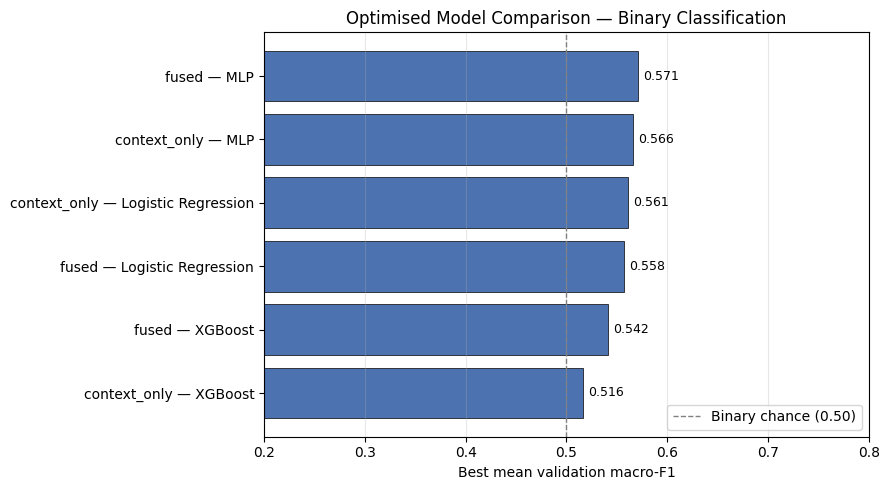

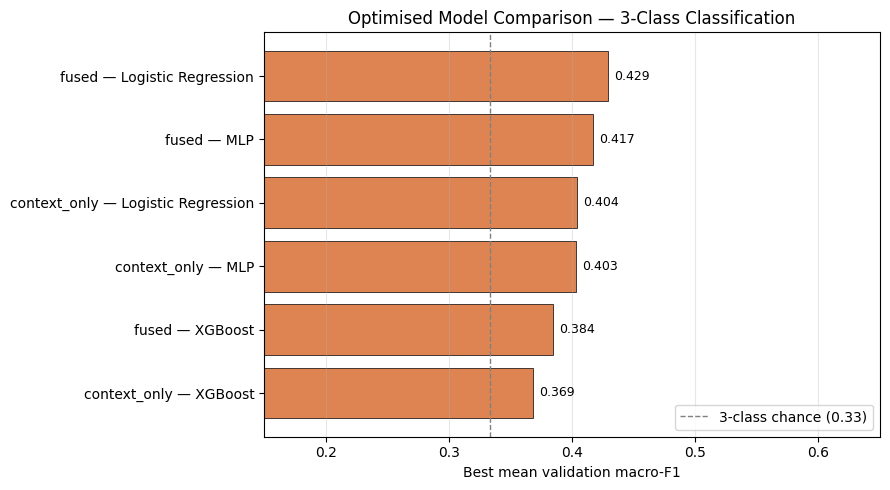

In [ ]:
optimised_plot_df = optimised_summary.copy()

optimised_plot_df["model_label"] = (
    optimised_plot_df["feature_set"] + " — " + optimised_plot_df["model"]
)


binary_optimised_plot_df = optimised_plot_df[
    optimised_plot_df["target"] == "binary"
].copy()

binary_optimised_plot_df = binary_optimised_plot_df.sort_values(
    by="validation_macro_f1",
    ascending=True
)


plt.figure(figsize=(9, 5))

bars = plt.barh(
    binary_optimised_plot_df["model_label"],
    binary_optimised_plot_df["validation_macro_f1"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5
)

for bar, value in zip(bars, binary_optimised_plot_df["validation_macro_f1"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.axvline(
    0.50,
    linestyle="--",
    linewidth=1,
    color="grey",
    label="Binary chance (0.50)"
)

plt.xlabel("Best mean validation macro-F1")
plt.title("Optimised Model Comparison — Binary Classification")
plt.xlim(0.2, 0.8)
plt.grid(axis="x", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


threeclass_optimised_plot_df = optimised_plot_df[
    optimised_plot_df["target"] == "3-class"
].copy()

threeclass_optimised_plot_df = threeclass_optimised_plot_df.sort_values(
    by="validation_macro_f1",
    ascending=True
)


plt.figure(figsize=(9, 5))

bars = plt.barh(
    threeclass_optimised_plot_df["model_label"],
    threeclass_optimised_plot_df["validation_macro_f1"],
    color="#DD8452",
    edgecolor="black",
    linewidth=0.5
)

for bar, value in zip(bars, threeclass_optimised_plot_df["validation_macro_f1"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.axvline(
    1 / 3,
    linestyle="--",
    linewidth=1,
    color="grey",
    label="3-class chance (0.33)"
)

plt.xlabel("Best mean validation macro-F1")
plt.title("Optimised Model Comparison — 3-Class Classification")
plt.xlim(0.15, 0.65)
plt.grid(axis="x", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 38. Graph comparison

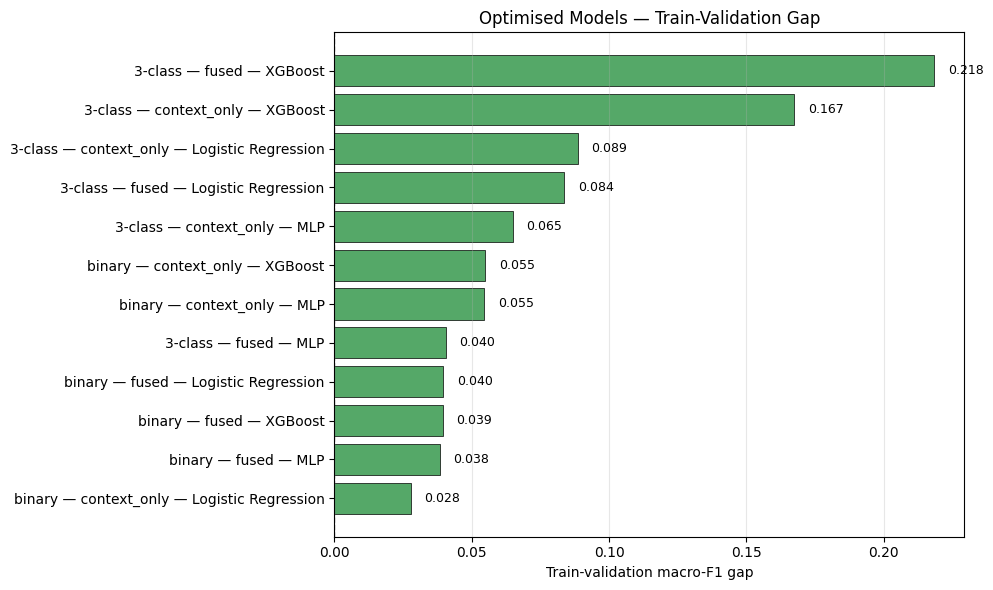

In [ ]:
gap_plot_df = optimised_summary.copy()

gap_plot_df["model_label"] = (
    gap_plot_df["target"] + " — " + gap_plot_df["feature_set"] + " — " + gap_plot_df["model"]
)

gap_plot_df = gap_plot_df.sort_values(
    by="train_validation_gap",
    ascending=True
)


plt.figure(figsize=(10, 6))

bars = plt.barh(
    gap_plot_df["model_label"],
    gap_plot_df["train_validation_gap"],
    color="#55A868",
    edgecolor="black",
    linewidth=0.5
)

for bar, value in zip(bars, gap_plot_df["train_validation_gap"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color="grey"
)

plt.xlabel("Train-validation macro-F1 gap")
plt.title("Optimised Models — Train-Validation Gap")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# **Final Tests**

# 39. Create final 2025 train/test masks

In [ ]:
final_train_mask = events["release_year"] < test_year
final_test_mask = events["release_year"] == test_year


print("Final train years:")
print(sorted(events.loc[final_train_mask, "release_year"].unique()))

print("\nFinal test year:")
print(test_year)

print("\nFinal train size:")
print(final_train_mask.sum())

print("\nFinal test size:")
print(final_test_mask.sum())

print("\nBinary test label counts:")
print(y_binary.loc[final_test_mask].value_counts().sort_index())

print("\n3-class test label counts:")
print(y_3class.loc[final_test_mask].value_counts().sort_index())

Final train years:
[np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]

Final test year:
2025

Final train size:
463

Final test size:
46

Binary test label counts:
label_binary
0    27
1    19
Name: count, dtype: int64

3-class test label counts:
label_3class_simple
0    18
1    12
2    16
Name: count, dtype: int64


# 40. Final test function for Logistic Regression

In [ ]:
def final_test_logistic(y_target, feature_set, output_size, best_params):

    if "pca_components" in best_params:
        pca_components = best_params["pca_components"]
    else:
        pca_components = 5

    if pca_components is None:
        pca_components = 5

    X_train, X_test, y_train, y_test = prepare_fold_features(
        final_train_mask,
        final_test_mask,
        y_target,
        feature_set,
        pca_components
    )

    model = LogisticRegression(
        C=best_params["C"],
        penalty=best_params["penalty"],
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_scores = get_classification_scores(y_train, train_predictions)
    test_scores = get_classification_scores(y_test, test_predictions)

    return model, X_train, X_test, y_train, y_test, train_predictions, test_predictions, train_scores, test_scores

# 41. Final test function for XGBoost

In [ ]:
def final_test_xgboost(y_target, feature_set, output_size, best_params):

    if "pca_components" in best_params:
        pca_components = best_params["pca_components"]
    else:
        pca_components = 5

    if pca_components is None:
        pca_components = 5

    X_train, X_test, y_train, y_test = prepare_fold_features(
        final_train_mask,
        final_test_mask,
        y_target,
        feature_set,
        pca_components
    )

    if output_size == 2:

        negative_count = (y_train == 0).sum()
        positive_count = (y_train == 1).sum()

        if positive_count > 0:
            scale_pos_weight = negative_count / positive_count
        else:
            scale_pos_weight = 1

        model = XGBClassifier(
            n_estimators=best_params["n_estimators"],
            max_depth=best_params["max_depth"],
            learning_rate=best_params["learning_rate"],
            min_child_weight=best_params["min_child_weight"],
            subsample=best_params["subsample"],
            colsample_bytree=best_params["colsample_bytree"],
            reg_lambda=best_params["reg_lambda"],
            reg_alpha=best_params["reg_alpha"],
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42
        )

        model.fit(X_train, y_train)

    else:

        sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

        model = XGBClassifier(
            n_estimators=best_params["n_estimators"],
            max_depth=best_params["max_depth"],
            learning_rate=best_params["learning_rate"],
            min_child_weight=best_params["min_child_weight"],
            subsample=best_params["subsample"],
            colsample_bytree=best_params["colsample_bytree"],
            reg_lambda=best_params["reg_lambda"],
            reg_alpha=best_params["reg_alpha"],
            objective="multi:softprob",
            num_class=output_size,
            eval_metric="mlogloss",
            random_state=42
        )

        model.fit(X_train, y_train, sample_weight=sample_weights)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_scores = get_classification_scores(y_train, train_predictions)
    test_scores = get_classification_scores(y_test, test_predictions)

    return model, X_train, X_test, y_train, y_test, train_predictions, test_predictions, train_scores, test_scores

# 42. Train MLP on full training data for a fixed number of epochs

In [ ]:
def train_mlp_for_epochs(X_train, y_train, output_size, hidden_size, learning_rate, weight_decay, batch_size, epochs):

    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    input_size = X_train.shape[1]

    model = EventMLP(input_size, hidden_size, output_size).to(device)

    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = loss_function(outputs, y_batch)

            loss.backward()
            optimizer.step()

    return model

# 43. Final test function for MLP

In [ ]:
def final_test_mlp(y_target, feature_set, output_size, best_params, final_epoch):

    if "pca_components" in best_params:
        pca_components = best_params["pca_components"]
    else:
        pca_components = 5

    if pca_components is None:
        pca_components = 5

    X_train, X_test, y_train, y_test = prepare_fold_features(
        final_train_mask,
        final_test_mask,
        y_target,
        feature_set,
        pca_components
    )

    set_all_seeds(42)

    model = train_mlp_for_epochs(
        X_train,
        y_train,
        output_size,
        best_params["hidden_size"],
        best_params["learning_rate"],
        best_params["weight_decay"],
        best_params["batch_size"],
        final_epoch
    )

    train_predictions = predict_mlp_model(model, X_train, best_params["batch_size"])
    test_predictions = predict_mlp_model(model, X_test, best_params["batch_size"])

    train_scores = get_classification_scores(y_train, train_predictions)
    test_scores = get_classification_scores(y_test, test_predictions)

    return model, X_train, X_test, y_train, y_test, train_predictions, test_predictions, train_scores, test_scores, final_epoch

# 44. Run final 2025 tests for optimised models

In [ ]:
final_test_rows = []
final_model_outputs = {}

all_studies = []

for key in binary_studies:
    all_studies.append(("binary", key[0], key[1], binary_studies[key], y_binary, 2))

for key in threeclass_studies:
    all_studies.append(("3-class", key[0], key[1], threeclass_studies[key], y_3class, 3))


for item in all_studies:

    target_name = item[0]
    feature_set = item[1]
    model_name = item[2]
    study = item[3]
    y_target = item[4]
    output_size = item[5]

    print("\nTesting:", target_name, feature_set, model_name)

    best_params = study.best_params

    if model_name == "Logistic Regression":

        output = final_test_logistic(y_target, feature_set, output_size, best_params)

        model = output[0]
        X_train = output[1]
        X_test = output[2]
        y_train = output[3]
        y_test = output[4]
        train_predictions = output[5]
        test_predictions = output[6]
        train_scores = output[7]
        test_scores = output[8]

        best_epoch = None

    elif model_name == "XGBoost":

        output = final_test_xgboost(y_target, feature_set, output_size, best_params)

        model = output[0]
        X_train = output[1]
        X_test = output[2]
        y_train = output[3]
        y_test = output[4]
        train_predictions = output[5]
        test_predictions = output[6]
        train_scores = output[7]
        test_scores = output[8]

        best_epoch = None

    else:

        final_epoch = int(study.best_trial.user_attrs["median_best_epoch"])

        output = final_test_mlp(y_target, feature_set, output_size, best_params, final_epoch)

        model = output[0]
        X_train = output[1]
        X_test = output[2]
        y_train = output[3]
        y_test = output[4]
        train_predictions = output[5]
        test_predictions = output[6]
        train_scores = output[7]
        test_scores = output[8]
        best_epoch = output[9]


    final_model_outputs[(target_name, feature_set, model_name)] = {
        "model": model,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "train_predictions": train_predictions,
        "test_predictions": test_predictions,
        "best_params": best_params,
        "best_epoch": best_epoch
    }


    final_test_rows.append({
        "target": target_name,
        "feature_set": feature_set,
        "model": model_name,
        "validation_macro_f1": study.best_value,
        "test_accuracy": test_scores["accuracy"],
        "test_balanced_accuracy": test_scores["balanced_accuracy"],
        "test_macro_f1": test_scores["macro_f1"],
        "final_train_macro_f1": train_scores["macro_f1"],
        "train_test_gap": train_scores["macro_f1"] - test_scores["macro_f1"],
        "best_epoch": best_epoch
    })


final_test_summary = pd.DataFrame(final_test_rows)

final_test_summary = final_test_summary.sort_values(
    by=["target", "test_macro_f1"],
    ascending=[True, False]
).reset_index(drop=True)

display(final_test_summary)


Testing: binary context_only Logistic Regression

Testing: binary context_only XGBoost

Testing: binary context_only MLP

Testing: binary fused Logistic Regression

Testing: binary fused XGBoost

Testing: binary fused MLP

Testing: 3-class context_only Logistic Regression

Testing: 3-class context_only XGBoost

Testing: 3-class context_only MLP

Testing: 3-class fused Logistic Regression

Testing: 3-class fused XGBoost

Testing: 3-class fused MLP


,target,feature_set,model,validation_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,final_train_macro_f1,train_test_gap,best_epoch
0,3-class,context_only,Logistic Regression,0.403847,0.500000,0.520833,0.502550,0.468933,-0.033617,NaN
1,3-class,fused,Logistic Regression,0.429286,0.478261,0.500000,0.482768,0.475310,-0.007459,NaN
2,3-class,context_only,MLP,0.402889,0.434783,0.451389,0.429896,0.451183,0.021286,16.0
3,3-class,context_only,XGBoost,0.368577,0.413043,0.423611,0.424755,0.549537,0.124782,NaN
4,3-class,fused,XGBoost,0.384306,0.391304,0.405093,0.392593,0.587747,0.195155,NaN
5,3-class,fused,MLP,0.416756,0.413043,0.405093,0.386420,0.457948,0.071528,16.0
6,binary,context_only,MLP,0.565561,0.543478,0.548733,0.541528,0.622290,0.080762,10.0
7,binary,fused,MLP,0.570816,0.521739,0.530214,0.520833,0.620606,0.099773,10.0
8,binary,context_only,XGBoost,0.516193,0.500000,0.519493,0.499764,0.591762,0.091999,NaN
9,binary,context_only,Logistic Regression,0.561330,0.500000,0.503899,0.497864,0.583122,0.085258,NaN


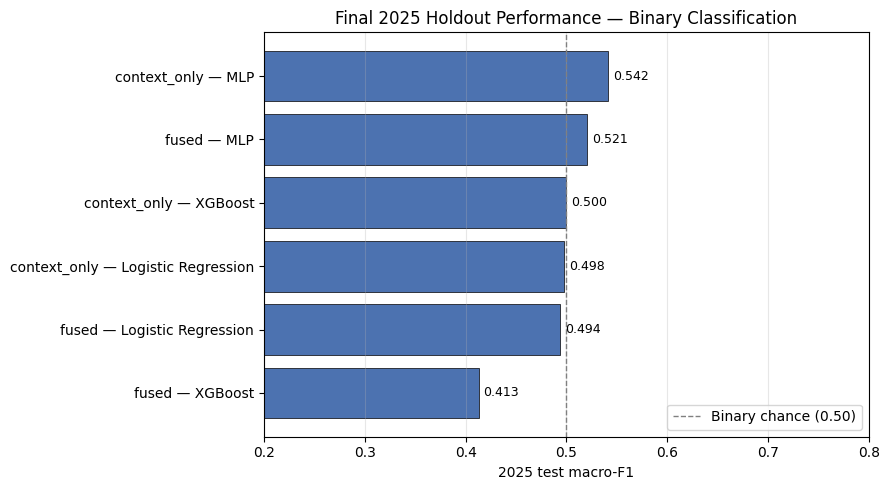

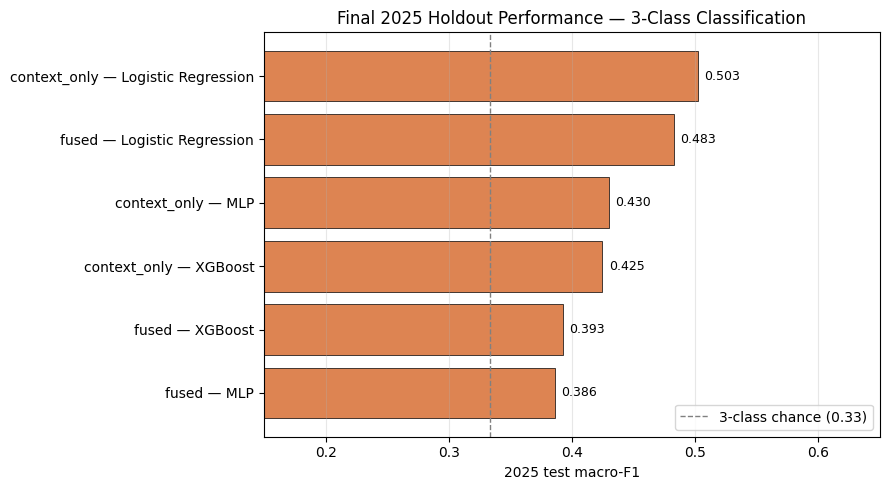

In [ ]:
final_plot_df = final_test_summary.copy()

final_plot_df["model_label"] = (
    final_plot_df["feature_set"] + " — " + final_plot_df["model"]
)


binary_final_plot_df = final_plot_df[
    final_plot_df["target"] == "binary"
].copy()

binary_final_plot_df = binary_final_plot_df.sort_values(
    by="test_macro_f1",
    ascending=True
)


plt.figure(figsize=(9, 5))

bars = plt.barh(
    binary_final_plot_df["model_label"],
    binary_final_plot_df["test_macro_f1"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5
)

for bar, value in zip(bars, binary_final_plot_df["test_macro_f1"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.axvline(
    0.50,
    linestyle="--",
    linewidth=1,
    color="grey",
    label="Binary chance (0.50)"
)

plt.xlabel("2025 test macro-F1")
plt.title("Final 2025 Holdout Performance — Binary Classification")
plt.xlim(0.2, 0.8)
plt.grid(axis="x", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


threeclass_final_plot_df = final_plot_df[
    final_plot_df["target"] == "3-class"
].copy()

threeclass_final_plot_df = threeclass_final_plot_df.sort_values(
    by="test_macro_f1",
    ascending=True
)


plt.figure(figsize=(9, 5))

bars = plt.barh(
    threeclass_final_plot_df["model_label"],
    threeclass_final_plot_df["test_macro_f1"],
    color="#DD8452",
    edgecolor="black",
    linewidth=0.5
)

for bar, value in zip(bars, threeclass_final_plot_df["test_macro_f1"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.axvline(
    1 / 3,
    linestyle="--",
    linewidth=1,
    color="grey",
    label="3-class chance (0.33)"
)

plt.xlabel("2025 test macro-F1")
plt.title("Final 2025 Holdout Performance — 3-Class Classification")
plt.xlim(0.15, 0.65)
plt.grid(axis="x", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
binary_final_results = final_test_summary[
    final_test_summary["target"] == "binary"
].copy()

threeclass_final_results = final_test_summary[
    final_test_summary["target"] == "3-class"
].copy()


best_binary_row = binary_final_results.sort_values(
    by="test_macro_f1",
    ascending=False
).iloc[0]

best_threeclass_row = threeclass_final_results.sort_values(
    by="test_macro_f1",
    ascending=False
).iloc[0]


print("Best binary 2025 model:")
display(best_binary_row.to_frame().T)

print("\nBest 3-class 2025 model:")
display(best_threeclass_row.to_frame().T)

Best binary 2025 model:


,target,feature_set,model,validation_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,final_train_macro_f1,train_test_gap,best_epoch
6,binary,context_only,MLP,0.565561,0.543478,0.548733,0.541528,0.62229,0.080762,10.0



Best 3-class 2025 model:


,target,feature_set,model,validation_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,final_train_macro_f1,train_test_gap,best_epoch
0,3-class,context_only,Logistic Regression,0.403847,0.5,0.520833,0.50255,0.468933,-0.033617,NaN


Selected binary model:
context_only MLP


,Predicted DOWN,Predicted UP
Actual DOWN,14,13
Actual UP,8,11


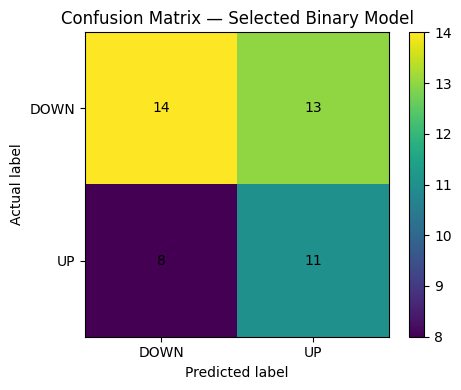


Classification report:
              precision    recall  f1-score   support

        DOWN       0.64      0.52      0.57        27
          UP       0.46      0.58      0.51        19

    accuracy                           0.54        46
   macro avg       0.55      0.55      0.54        46
weighted avg       0.56      0.54      0.55        46



In [ ]:
selected_target = best_binary_row["target"]
selected_feature_set = best_binary_row["feature_set"]
selected_model_name = best_binary_row["model"]

selected_output = final_model_outputs[
    (
        selected_target,
        selected_feature_set,
        selected_model_name
    )
]

y_test_selected = selected_output["y_test"]
test_predictions_selected = selected_output["test_predictions"]


cm = confusion_matrix(
    y_test_selected,
    test_predictions_selected,
    labels=[0, 1]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual DOWN", "Actual UP"],
    columns=["Predicted DOWN", "Predicted UP"]
)

print("Selected binary model:")
print(selected_feature_set, selected_model_name)

display(cm_df)


plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.xticks(
    ticks=[0, 1],
    labels=["DOWN", "UP"]
)

plt.yticks(
    ticks=[0, 1],
    labels=["DOWN", "UP"]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix — Selected Binary Model")

plt.colorbar()
plt.tight_layout()
plt.show()


print("\nClassification report:")
print(
    classification_report(
        y_test_selected,
        test_predictions_selected,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

Selected 3-class model:
context_only Logistic Regression


,Predicted DOWN,Predicted NEUTRAL,Predicted UP
Actual DOWN,6,2,10
Actual NEUTRAL,2,8,2
Actual UP,2,5,9


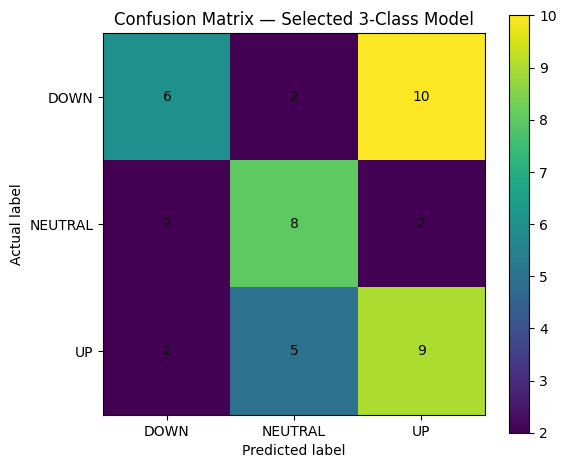


Classification report:
              precision    recall  f1-score   support

        DOWN       0.60      0.33      0.43        18
     NEUTRAL       0.53      0.67      0.59        12
          UP       0.43      0.56      0.49        16

    accuracy                           0.50        46
   macro avg       0.52      0.52      0.50        46
weighted avg       0.52      0.50      0.49        46



In [ ]:
selected_target = best_threeclass_row["target"]
selected_feature_set = best_threeclass_row["feature_set"]
selected_model_name = best_threeclass_row["model"]

selected_output = final_model_outputs[
    (
        selected_target,
        selected_feature_set,
        selected_model_name
    )
]

y_test_selected = selected_output["y_test"]
test_predictions_selected = selected_output["test_predictions"]


cm = confusion_matrix(
    y_test_selected,
    test_predictions_selected,
    labels=[0, 1, 2]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual DOWN", "Actual NEUTRAL", "Actual UP"],
    columns=["Predicted DOWN", "Predicted NEUTRAL", "Predicted UP"]
)

print("Selected 3-class model:")
print(selected_feature_set, selected_model_name)

display(cm_df)


plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    ticks=[0, 1, 2],
    labels=["DOWN", "NEUTRAL", "UP"]
)

plt.yticks(
    ticks=[0, 1, 2],
    labels=["DOWN", "NEUTRAL", "UP"]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix — Selected 3-Class Model")

plt.colorbar()
plt.tight_layout()
plt.show()


print("\nClassification report:")
print(
    classification_report(
        y_test_selected,
        test_predictions_selected,
        target_names=["DOWN", "NEUTRAL", "UP"],
        zero_division=0
    )
)

In [ ]:

surprise_map = {
    "CPI": "headline_cpi_mom_surprise",
    "GDP_ADVANCE": "gdp_growth_rate_qoq_advance_surprise",
    "NFP": "nonfarm_payrolls_surprise",
    "PCE": "core_pce_price_index_mom_surprise",
    "RETAIL_SALES": "retail_sales_mom_surprise"
}


correlation_rows = []

for event_type in surprise_map:

    surprise_column = surprise_map[event_type]

    event_df = events[
        events["event_type"] == event_type
    ].copy()

    event_df = event_df[
        event_df[surprise_column].notna()
    ].copy()

    for year in sorted(event_df["release_year"].unique()):

        year_df = event_df[
            event_df["release_year"] == year
        ].copy()

        n_events = len(year_df)

        if n_events >= 3:

            pearson_corr = year_df[surprise_column].corr(
                year_df[return_column],
                method="pearson"
            )

            spearman_corr = year_df[surprise_column].corr(
                year_df[return_column],
                method="spearman"
            )

        else:

            pearson_corr = np.nan
            spearman_corr = np.nan


        correlation_rows.append({
            "event_type": event_type,
            "surprise_column": surprise_column,
            "year": year,
            "n_events": n_events,
            "pearson_surprise_return_corr": pearson_corr,
            "spearman_surprise_return_corr": spearman_corr
        })


yearly_surprise_correlation_df = pd.DataFrame(correlation_rows)

display(yearly_surprise_correlation_df)

,event_type,surprise_column,year,n_events,pearson_surprise_return_corr,spearman_surprise_return_corr
0,CPI,headline_cpi_mom_surprise,2016,12,-0.158323,-0.238839
1,CPI,headline_cpi_mom_surprise,2017,11,-0.665644,-0.683436
2,CPI,headline_cpi_mom_surprise,2018,12,-0.430927,-0.025921
3,CPI,headline_cpi_mom_surprise,2019,12,-0.471497,-0.566928
4,CPI,headline_cpi_mom_surprise,2020,11,-0.056557,-0.185655
5,CPI,headline_cpi_mom_surprise,2021,12,0.033496,0.017829
6,CPI,headline_cpi_mom_surprise,2022,12,-0.753394,-0.739880
7,CPI,headline_cpi_mom_surprise,2023,12,-0.549143,-0.470274
8,CPI,headline_cpi_mom_surprise,2024,12,-0.263556,-0.368265
9,CPI,headline_cpi_mom_surprise,2025,10,0.433147,0.642085


In [ ]:
comparison_rows = []

for event_type in surprise_map:

    surprise_column = surprise_map[event_type]

    event_df = events[
        events["event_type"] == event_type
    ].copy()

    event_df = event_df[
        event_df[surprise_column].notna()
    ].copy()


    validation_df = event_df[
        event_df["release_year"].isin([2020, 2021, 2022, 2023, 2024])
    ].copy()

    test_2025_df = event_df[
        event_df["release_year"] == 2025
    ].copy()


    validation_pearson = validation_df[surprise_column].corr(
        validation_df[return_column],
        method="pearson"
    )

    validation_spearman = validation_df[surprise_column].corr(
        validation_df[return_column],
        method="spearman"
    )

    test_pearson = test_2025_df[surprise_column].corr(
        test_2025_df[return_column],
        method="pearson"
    )

    test_spearman = test_2025_df[surprise_column].corr(
        test_2025_df[return_column],
        method="spearman"
    )


    comparison_rows.append({
        "event_type": event_type,
        "surprise_column": surprise_column,
        "validation_n": len(validation_df),
        "test_2025_n": len(test_2025_df),
        "validation_pearson_corr": validation_pearson,
        "test_2025_pearson_corr": test_pearson,
        "pearson_change": test_pearson - validation_pearson,
        "validation_spearman_corr": validation_spearman,
        "test_2025_spearman_corr": test_spearman,
        "spearman_change": test_spearman - validation_spearman
    })


surprise_correlation_comparison_df = pd.DataFrame(comparison_rows)

display(surprise_correlation_comparison_df)

,event_type,surprise_column,validation_n,test_2025_n,validation_pearson_corr,test_2025_pearson_corr,pearson_change,validation_spearman_corr,test_2025_spearman_corr,spearman_change
0,CPI,headline_cpi_mom_surprise,59,10,-0.327743,0.433147,0.760890,-0.402418,0.642085,1.044503
1,GDP_ADVANCE,gdp_growth_rate_qoq_advance_surprise,20,4,0.062392,0.392604,0.330212,0.150489,0.200000,0.049511
2,NFP,nonfarm_payrolls_surprise,60,11,0.185859,-0.050549,-0.236407,-0.083362,-0.113896,-0.030533
3,PCE,core_pce_price_index_mom_surprise,59,10,0.101820,-0.789094,-0.890915,0.039207,-0.741620,-0.780827
4,RETAIL_SALES,retail_sales_mom_surprise,60,11,0.201586,-0.094502,-0.296088,0.237371,-0.165145,-0.402516
